In [1]:
import numpy as np
import wildfire
from utils.functions import G
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm
import random 
import pickle

In [3]:


kap=0.1
eps = 0.3
upc = 3
alp = 0
q = 1
x_min, x_max = 0, 1
y_min, y_max = 0, 1
t_min, t_max = 0, 1
mu=1.25


def runSolver(physical_parameters):
    wildfire_ = wildfire.Fire(**physical_parameters)
    Nx=32   
    Ny = Nx
    Nt = 5 * Nx**2
    u0=lambda X, Y: np.exp(-((X-0.5)**2 + (Y-0.5)**2)/0.02) 
    b0 = lambda X, Y: np.ones_like(X)
    V=lambda x, y, t: (0*x, 0*y)
    t, X, Y, U, B = wildfire_.solvePDE(Nx, Ny, Nt, u0, b0, V, 'FD', 'RK4', last=True, acc=2, sparse=False)

    SRQ_betamax_num   = np.max(B)
    SRQ_umax_num   = np.max(U)
    return SRQ_umax_num



In [13]:
from tqdm import tqdm
from tqdm.notebook import tqdm
tqdm.pandas()

ne20_samples = np.linspace(0.08, 0.12, 25 + 1)
ne20_samples = np.linspace(0.08, 0.12, 25+ 1)
total_srq=[]
seedval=41
for k in range(0, len(ne20_samples)):
    SRQ50=[]
    print(f"Running for upc={ne20_samples[k]:.4f}")
    sampler50 = qmc.LatinHypercube(d=1, seed=seedval+k)
    sample50= sampler50.random(n=50)
    sample50 = sample50.flatten()
    sample50 = norm.ppf(sample50, loc=1.25, scale=0.25)
    sample50 = np.clip(sample50, 1e-6, None)
    print("Starting simulations...")
    for i in tqdm(range(len(sample50)), desc="Simulated samples", leave=False):
        physical_parameters = {    
            'kap': ne20_samples[k], # diffusion coefficient
            'eps': eps, # inverse of activation energy
            'upc': sample50[i], # u phase change
            'q': q, # reaction heat
            'alp': alp, 
            'x_lim': (x_min, x_max), # x-axis domain 
            'y_lim': (y_min, y_max), # y-axis domain
            't_lim': (t_min, t_max), # time domain
            'components':(True, False, True) #diffusion, convection, reaction
        }
        SRQ50.append(runSolver(physical_parameters)) 
    total_srq.append(SRQ50)
total_srq = np.array(total_srq)
print(total_srq.shape)

Running for upc=0.0800
Starting simulations...


Simulated samples:   0%|          | 0/50 [00:00<?, ?it/s]

Running for upc=0.0816
Starting simulations...


Simulated samples:   0%|          | 0/50 [00:00<?, ?it/s]

Running for upc=0.0832
Starting simulations...


...

Running for upc=0.1184
Starting simulations...


Simulated samples:   0%|          | 0/50 [00:00<?, ?it/s]

Running for upc=0.1200
Starting simulations...


Simulated samples:   0%|          | 0/50 [00:00<?, ?it/s]

(26, 50)


In [14]:
import pickle

with open("total_srq25.pkl", "wb") as f:
    pickle.dump(total_srq, f)


In [25]:
with open("total_srq10.pkl", "rb") as f:
    SRQ10 = pickle.load(f)
with open("total_srq15.pkl", "rb") as f:
    SRQ15 = pickle.load(f)
with open("total_srq20.pkl", "rb") as f:
    SRQ20 = pickle.load(f)
with open("total_srq25.pkl", "rb") as f:
    SRQ25 = pickle.load(f)

In [17]:
ne10_samples = list(np.linspace(0.08, 0.12, 10+ 1))
ne15_samples = list(np.linspace(0.08, 0.12, 15+ 1))
ne20_samples = list(np.linspace(0.08, 0.12, 20+ 1))
ne25_samples = list(np.linspace(0.08, 0.12, 25 + 1))

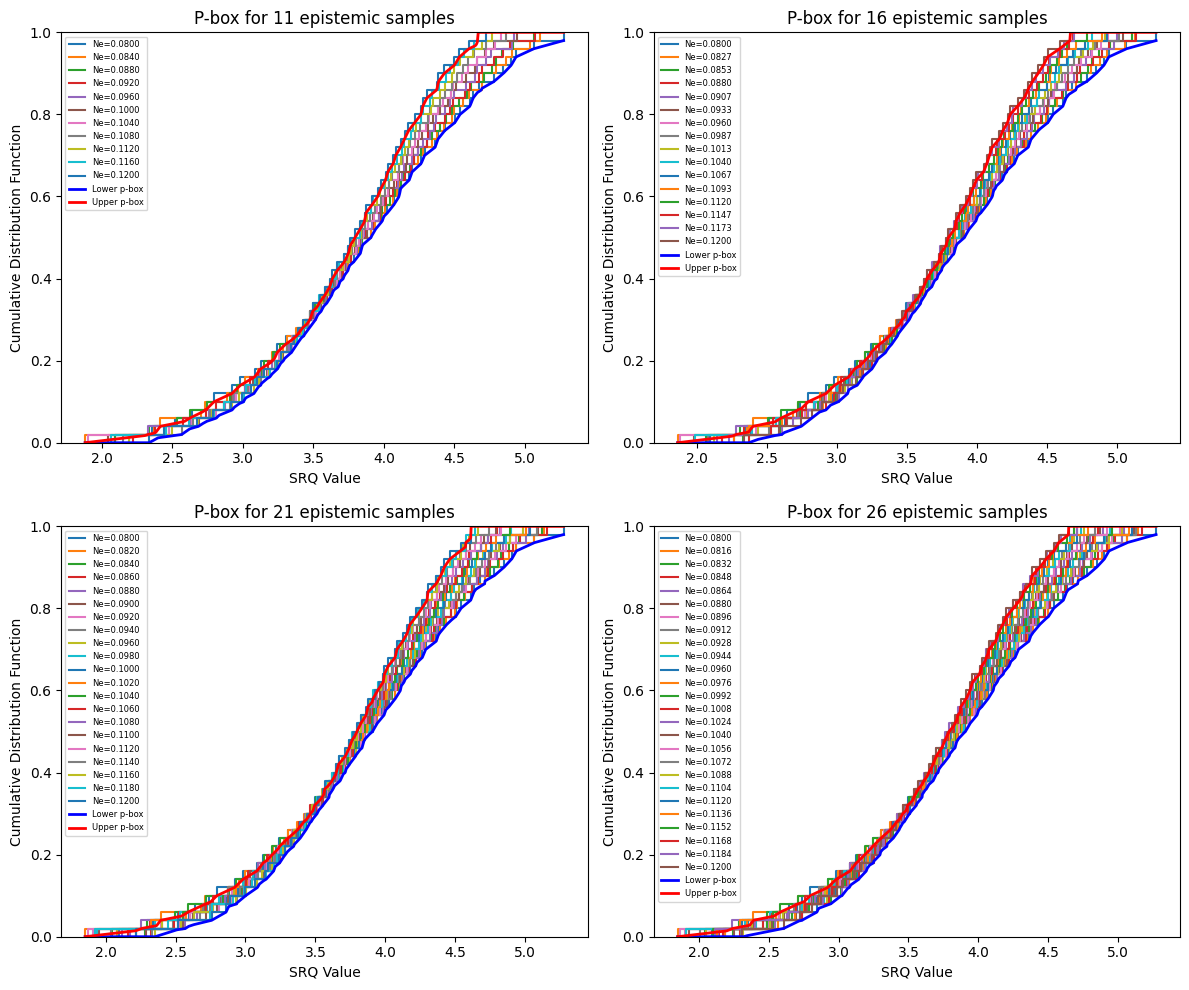

In [18]:
from statsmodels.distributions.empirical_distribution import ECDF
from collections import defaultdict
import math
from scipy.interpolate import interp1d
from scipy import stats
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (s, ne_samples, ne) in enumerate([(SRQ10, ne10_samples, 10), (SRQ15, ne15_samples, 15), (SRQ20, ne20_samples, 20), (SRQ25, ne25_samples, 25)]):
    ax = axes[idx//2, idx%2]
    for i in range(len(s)):
        s[i] = [v for v in s[i] if not math.isnan(v) and not math.isinf(v)]
    allcdfs=[]
    for i in range(len(s)):
        temp = s[i]
        ecdf = ECDF(temp)
        x = ecdf.x 
        x=[v for v in x if not math.isnan(v) and not math.isinf(v)]
        y = ecdf.y
        y=[v for v in y if not math.isnan(v) and not math.isinf(v)]
        coords=list(zip(x,y))
        allcdfs.append(coords)
    allcdfs = np.array(allcdfs)
    xval=allcdfs[:, :, 0]
    yval=allcdfs[:, :, 1]
    xpoints=np.linspace(xval.min(), xval.max(), ne*50)
    results=[]
    for i in range(len(allcdfs)):
        ax.ecdf(s[i], label=f"Ne={ne_samples[i]:.4f}")
        results.append(interp1d(xval[i], yval[i], kind='linear', fill_value=(0, 1), bounds_error=False))
    all_y = np.array([result(xpoints) for result in results])  
    pbox_lower = np.min(all_y, axis=0)
    pbox_upper = np.max(all_y, axis=0)
    ax.plot(xpoints, pbox_lower, linewidth=2, label='Lower p-box', color='blue')
    ax.plot(xpoints, pbox_upper, linewidth=2, label='Upper p-box', color='red')
    ax.legend(fontsize=6)
    ax.set_xlabel("SRQ Value")
    ax.set_ylabel("Cumulative Distribution Function")
    ax.set_title(f"P-box for {len(s)} epistemic samples")

plt.tight_layout()
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

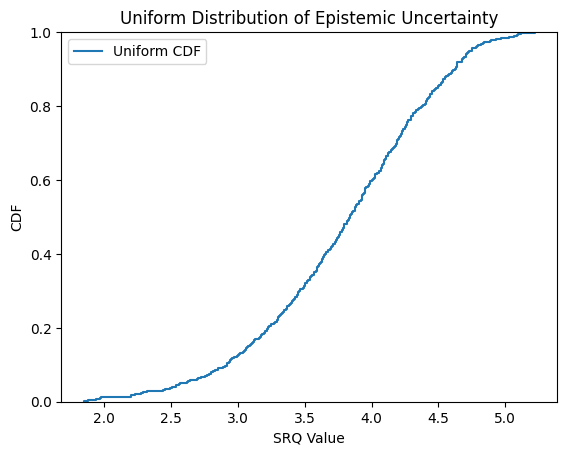

In [46]:
from scipy.stats import uniform
Na = 500
lhs = qmc.LatinHypercube(d=1, seed=seedval).random(n=Na).flatten()
kap_uniform = uniform.ppf(lhs, loc=0.08, scale=0.04)  # uniform samples of kap
lhs2 = qmc.LatinHypercube(d=1, seed=seedval+1).random(n=Na).flatten()
upc_samples = norm.ppf(lhs2, loc=1.25, scale=0.25)
upc_samples = np.clip(upc_samples, 1e-6, None)

srq_uniform = []
for i in tqdm(range(Na)):
    physical_parameters = {
        'kap': kap_uniform[i],
        'upc': upc_samples[i],
        'eps': eps,
        'q': q,
        'alp': alp,
        'x_lim': (x_min, x_max),
        'y_lim': (y_min, y_max),
        't_lim': (t_min, t_max),
        'components': (True, False, True)
    }
    srq_uniform.append(runSolver(physical_parameters))

fig, ax = plt.subplots()
ax.ecdf(srq_uniform, label='Uniform CDF')
ax.set_xlabel("SRQ Value")
ax.set_ylabel("CDF")
ax.set_title("Uniform Distribution of Epistemic Uncertainty")
ax.legend()
plt.show()

In [42]:
srq_uniform

[np.float64(3.4920512398764756),
 np.float64(4.720920745026487),
 np.float64(3.237742735592316),
 np.float64(4.334134537385473),
 np.float64(4.05274946118173),
 np.float64(4.567764439947055),
 np.float64(4.6104065498649485),
 np.float64(4.829508332392196),
 np.float64(4.172825805792155),
 np.float64(1.8404906915917556),
 np.float64(4.936604992518184),
 np.float64(3.946647918192572),
 np.float64(3.2912382631574166),
 np.float64(3.8602238110075975),
 np.float64(4.081008408357245),
 np.float64(2.7244025005467822),
 np.float64(3.574528787090039),
 np.float64(3.830050847320655),
 np.float64(3.9837912225651686),
 np.float64(4.337016519949027),
 np.float64(3.0656274788452205),
 np.float64(3.653262834781164),
 np.float64(4.493983045284664),
 np.float64(3.5545478889070443),
 np.float64(4.202574195650459),
 np.float64(3.3552368575960445),
 np.float64(3.813304206449041),
 np.float64(2.414845576780905),
 np.float64(4.117963698863814),
 np.float64(3.970248339131057),
 np.float64(3.6937230899632643)

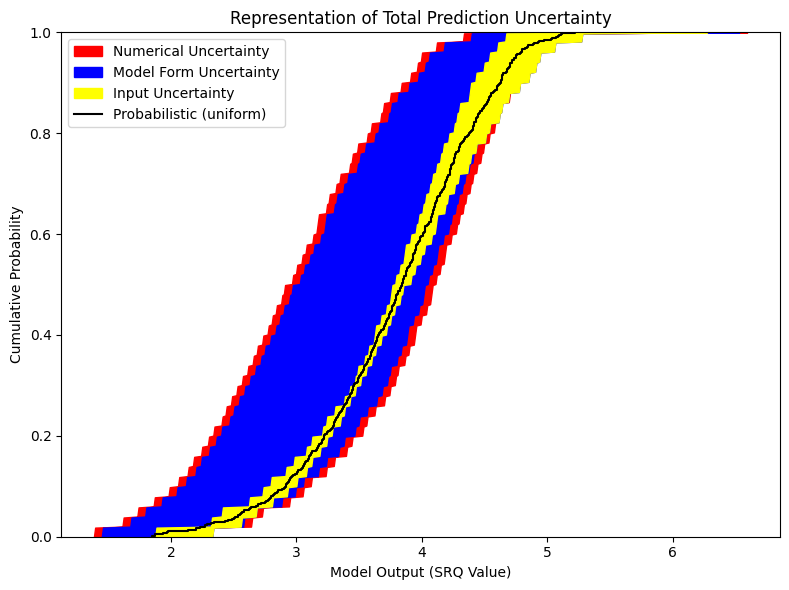

In [49]:

d_plus = 0.2573       
d_minus = 0.8803      
U_num = 0.062650    # total numerical uncertainty
srq_ensemble = [SRQ10[i] for i in range(len(SRQ10))]
all_srq = np.concatenate(srq_ensemble)
x_grid = np.linspace(all_srq.min() - 1, all_srq.max() + 1, 500)

cdfs = []
for srq_arr in srq_ensemble:
    cdf = np.array([np.mean(srq_arr <= x) for x in x_grid])
    cdfs.append(cdf)

cdf_matrix = np.array(cdfs)
lower_pbox = cdf_matrix.min(axis=0)  
upper_pbox = cdf_matrix.max(axis=0)  

# Shift x_grid for each layer
x_input_lower = x_grid         
x_input_upper = x_grid          

x_model_lower = x_grid - d_minus 
x_model_upper = x_grid + d_plus   

x_total_lower = x_grid - d_minus - U_num   
x_total_upper = x_grid + d_plus + U_num    

y_grid = np.linspace(0, 1, 500)

from scipy.interpolate import interp1d

x_lower_inv = interp1d(lower_pbox, x_grid, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
x_upper_inv = interp1d(upper_pbox, x_grid, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))

x_left  = x_lower_inv(y_grid)
x_right = x_upper_inv(y_grid)

x_blue_left  = x_left  - d_minus
x_blue_right = x_right + d_plus
x_red_left   = x_blue_left  - U_num
x_red_right  = x_blue_right + U_num

fig, ax = plt.subplots(figsize=(8, 6))

ax.fill_betweenx(y_grid, x_red_left,   x_blue_left,  color='red',    label='Numerical Uncertainty')
ax.fill_betweenx(y_grid, x_blue_right, x_red_right,  color='red')
ax.fill_betweenx(y_grid, x_blue_left,  x_left,       color='blue',   label='Model Form Uncertainty')
ax.fill_betweenx(y_grid, x_right,      x_blue_right, color='blue')
ax.fill_betweenx(y_grid, x_left,       x_right,      color='yellow', label='Input Uncertainty')

ax.ecdf(srq_uniform, color='black', linewidth=1.5, label='Probabilistic (uniform)')
ax.set_xlabel("Model Output (SRQ Value)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Representation of Total Prediction Uncertainty")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
np.array(SRQ10).shape

(11, 50)